Dataset Shape: (1000, 12)
  Farm_ID Governorate Animal_Type  Farm_Size Disease_Detected Vaccinated  \
0   F0001       Sohag     Poultry       2102  Avian Influenza        Yes   
1   F0002     Sharqia      Cattle         87              PPR        Yes   
2   F0003       Sohag        Goat         95              PPR         No   
3   F0004   Beni Suef     Poultry       2881        Newcastle        Yes   
4   F0005   Beni Suef       Sheep        163         Foot Rot        Yes   

   Outbreak_Cases  Deaths Vet_Visit Treatment_Used  Economic_Loss_EGP Month  
0             572      84       Yes      Antiviral              18564   Oct  
1               6       0        No     Supportive                  0   Apr  
2              27       1        No     Supportive                231   May  
3             971     179        No     Supportive              35263   Jun  
4              10       2        No    Antibiotics                426   Nov  

Linear Regression Performance
MAE: 7557.27052488

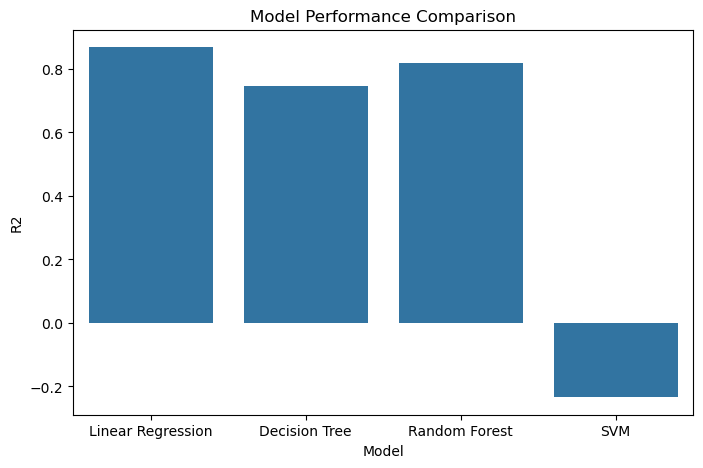

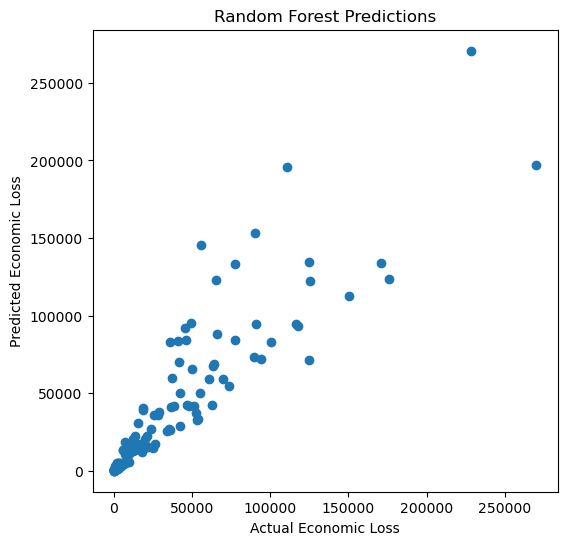

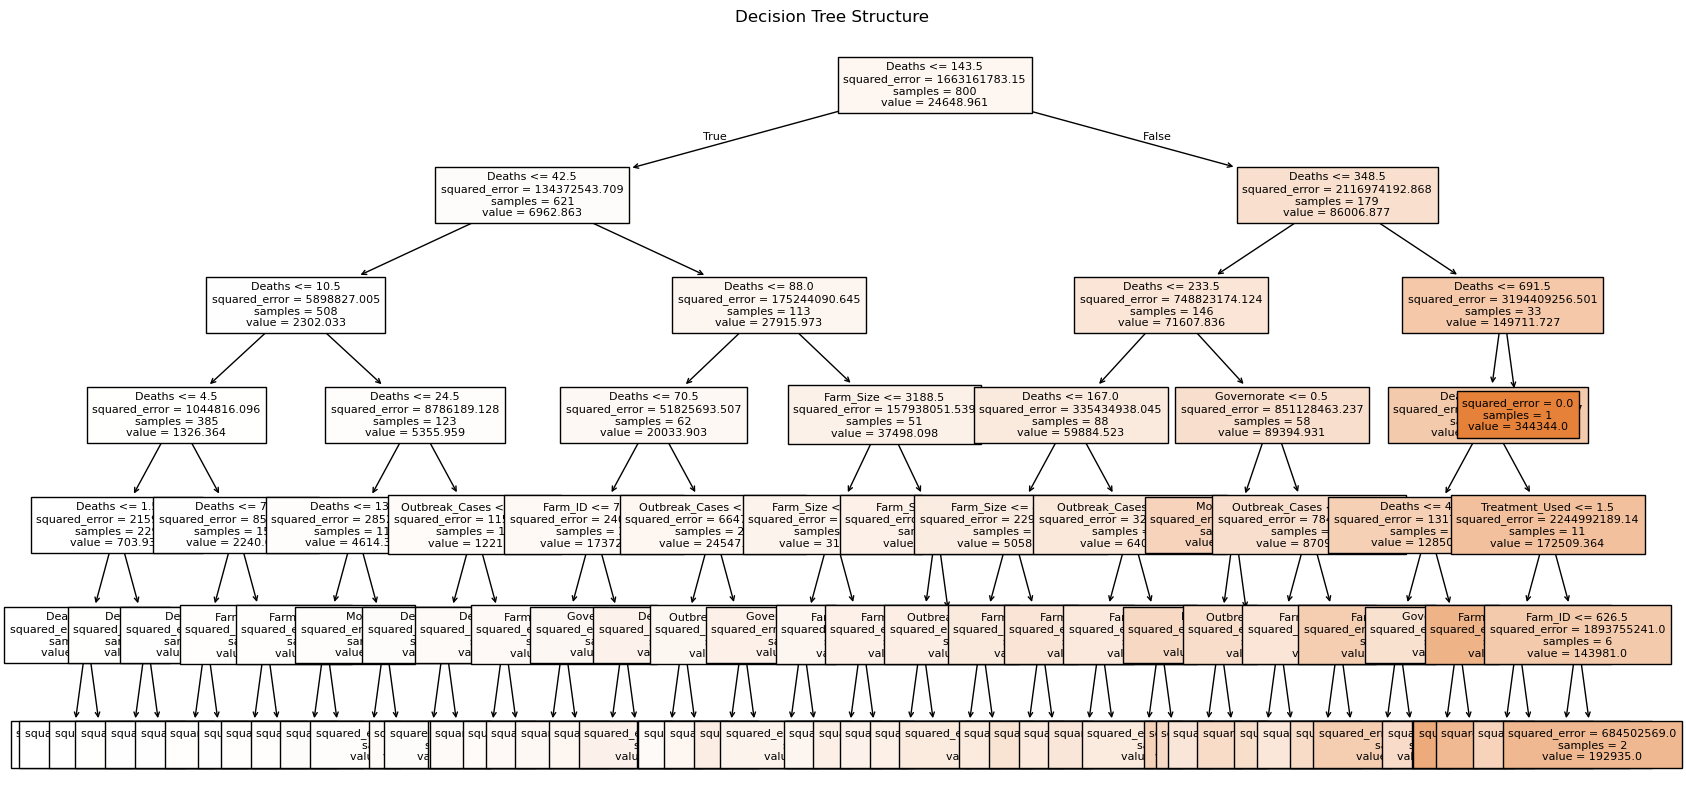


Feature Importance
             Feature  Importance
7             Deaths    0.909751
6     Outbreak_Cases    0.021315
0            Farm_ID    0.020092
3          Farm_Size    0.015849
10             Month    0.013093
1        Governorate    0.012256
8          Vet_Visit    0.002214
9     Treatment_Used    0.002070
5         Vaccinated    0.001836
4   Disease_Detected    0.001516
2        Animal_Type    0.000009


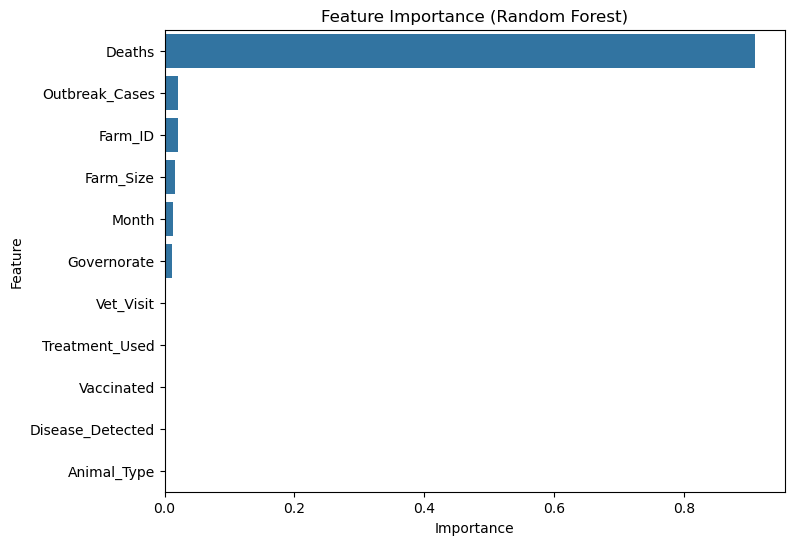

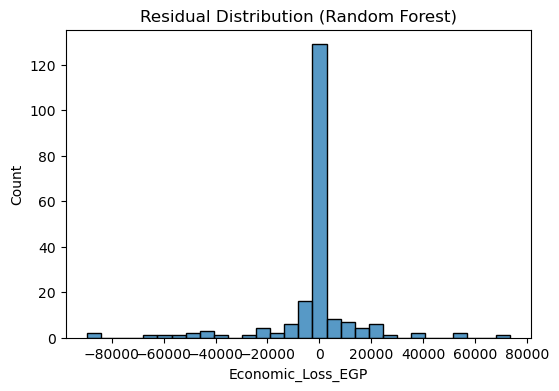

In [12]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_excel("veterinary_disease_outbreak_egypt_dataset.xlsx")

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Encode Categorical Features
# ==========================================

# Convert categorical variables into numeric values
data = df.copy()

le = LabelEncoder()

for col in data.select_dtypes(include="object").columns:
    data[col] = le.fit_transform(data[col])

# ==========================================
# 4. Define Features and Target
# ==========================================

target = "Economic_Loss_EGP"

X = data.drop(target, axis=1)
y = data[target]

# ==========================================
# 5. Train-Test Split
# ==========================================

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 6. Feature Scaling
# ==========================================

# Scaling improves performance for SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 7. Initialize Models
# ==========================================

lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
svm = SVR(kernel='rbf')

# ==========================================
# 8. Train Models
# ==========================================

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

svm.fit(X_train_scaled, y_train)

# ==========================================
# 9. Predictions
# ==========================================

pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_rf = rf.predict(X_test)
pred_svm = svm.predict(X_test_scaled)

# ==========================================
# 10. Model Evaluation Function
# ==========================================

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Performance")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    return mae, rmse, r2

# Evaluate models
lr_results = evaluate_model("Linear Regression", y_test, pred_lr)
dt_results = evaluate_model("Decision Tree", y_test, pred_dt)
rf_results = evaluate_model("Random Forest", y_test, pred_rf)
svm_results = evaluate_model("SVM", y_test, pred_svm)

# ==========================================
# 11. Model Comparison Table
# ==========================================

results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree","Random Forest","SVM"],
    "MAE": [lr_results[0],dt_results[0],rf_results[0],svm_results[0]],
    "RMSE":[lr_results[1],dt_results[1],rf_results[1],svm_results[1]],
    "R2":[lr_results[2],dt_results[2],rf_results[2],svm_results[2]]
})

print("\nModel Comparison")
print(results)

# ==========================================
# 12. Model Performance Visualization
# ==========================================

plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="R2")
plt.title("Model Performance Comparison")
plt.show()

# ==========================================
# 13. Actual vs Predicted Plot
# ==========================================

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Economic Loss")
plt.ylabel("Predicted Economic Loss")
plt.title("Random Forest Predictions")
plt.show()

# ==========================================
# 14. Decision Tree Visualization
# ==========================================

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Structure")
plt.show()

# ==========================================
# 15. Random Forest Feature Importance
# ==========================================

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance (Random Forest)")
plt.show()

# ==========================================
# 16. Residual Plot
# ==========================================

residuals = y_test - pred_rf

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30)
plt.title("Residual Distribution (Random Forest)")
plt.show()

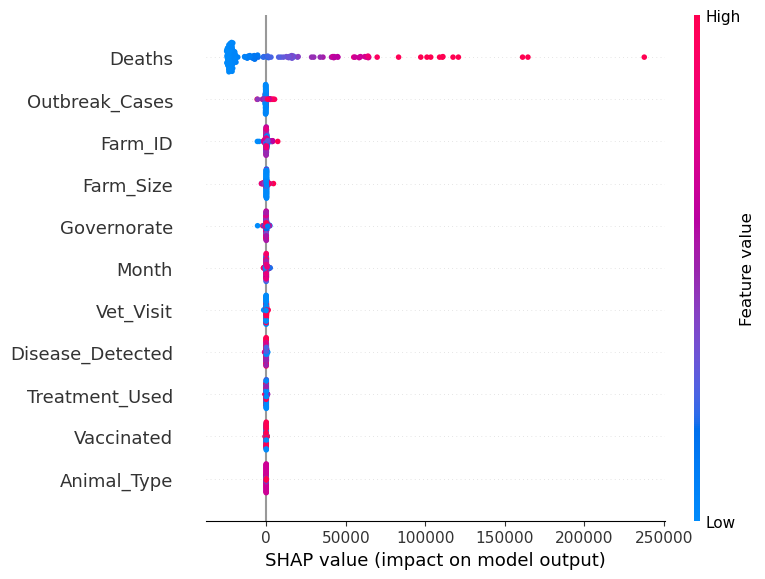

In [14]:
# ==========================================
# SHAP Analysis
# ==========================================

import shap

# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test)

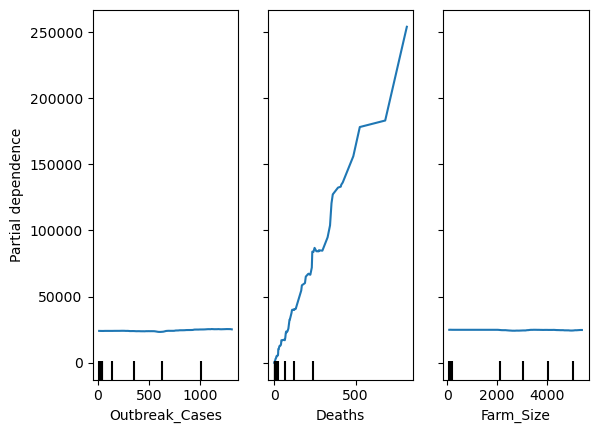

In [7]:
#Partial Dependence Plot
from sklearn.inspection import PartialDependenceDisplay

features = ["Outbreak_Cases", "Deaths", "Farm_Size"]

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features
)

plt.show()

In [10]:
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )
    
    print(f"{name} Average R2:", scores.mean())

Linear Regression Average R2: 0.8701067299837624
Decision Tree Average R2: 0.7785260950704436
Random Forest Average R2: 0.8384417506941488


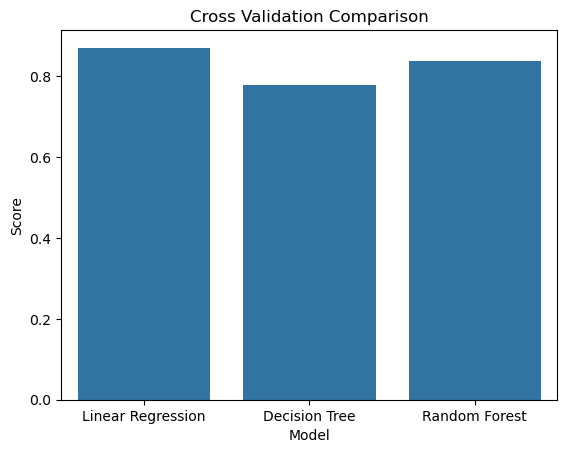

In [11]:
#Cross Validation Comparison
cv_results = []

for name, model in models.items():
    
    scores = cross_val_score(model, X, y, cv=5)
    
    cv_results.append({
        "Model": name,
        "Score": scores.mean()
    })

cv_df = pd.DataFrame(cv_results)

sns.barplot(data=cv_df, x="Model", y="Score")
plt.title("Cross Validation Comparison")
plt.show()